<a href="https://colab.research.google.com/github/AmaraRao19/HousePricePrediction/blob/main/HousePricePrediction_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load Libraries and Data

In [ ]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Boston Housing/housing.csv")

print("Dataset Preview:\n")
print(df.head())

print("\n\nDataset Information:\n")
df.info()

print("\n\nStatistical Summary:\n")
print(df.describe())

print(df.columns)

Dataset Preview:

      RM  LSTAT  PTRATIO      MEDV
0  6.575   4.98     15.3  504000.0
1  6.421   9.14     17.8  453600.0
2  7.185   4.03     17.8  728700.0
3  6.998   2.94     18.7  701400.0
4  7.147   5.33     18.7  760200.0


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RM       489 non-null    float64
 1   LSTAT    489 non-null    float64
 2   PTRATIO  489 non-null    float64
 3   MEDV     489 non-null    float64
dtypes: float64(4)
memory usage: 15.4 KB


Statistical Summary:

               RM       LSTAT     PTRATIO          MEDV
count  489.000000  489.000000  489.000000  4.890000e+02
mean     6.240288   12.939632   18.516564  4.543429e+05
std      0.643650    7.081990    2.111268  1.653403e+05
min      3.561000    1.980000   12.600000  1.050000e+05
25%      5.880000    7.370000   17.400000  3.507000e+05
50%      6.1850

#Data Preprocessing


Check Missing Values

In [ ]:
print(df.isnull().sum())

RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64


Remove Rows with Missing Values (dropna)

In [ ]:
df = df.dropna()

Fill Missing Values

In [ ]:
# Fill Numerical Columns with Mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill Categorical Columns with Mode
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Show missing values AFTER
print("\n Missing Values AFTER Handling:\n")
print(df.isnull().sum())

# Show sample data
print("\n Updated Dataset Preview:\n")
print(df.head())


 Missing Values AFTER Handling:

RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64

 Updated Dataset Preview:

      RM  LSTAT  PTRATIO      MEDV
0  6.575   4.98     15.3  504000.0
1  6.421   9.14     17.8  453600.0
2  7.185   4.03     17.8  728700.0
3  6.998   2.94     18.7  701400.0
4  7.147   5.33     18.7  760200.0


Remove Duplicates

In [ ]:
#Check Duplicate Rows
print(df.duplicated().sum())

#Remove Duplicate Rows
df = df.drop_duplicates()

0


#Data Transformation

Encoding Categorical Data

In [ ]:
import pandas as pd

# Step 1: Check data types
print(df.dtypes)

# Step 2: Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:", cat_cols)

# Step 3: Label Encoding for ordinal categorical columns (if any)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Step 4: One-Hot Encoding for nominal categorical columns (if any)
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Step 5: Check the updated dataframe
print(df.head())

RM         float64
LSTAT      float64
PTRATIO    float64
MEDV       float64
dtype: object
Categorical columns: Index([], dtype='object')
      RM  LSTAT  PTRATIO      MEDV
0  6.575   4.98     15.3  504000.0
1  6.421   9.14     17.8  453600.0
2  7.185   4.03     17.8  728700.0
3  6.998   2.94     18.7  701400.0
4  7.147   5.33     18.7  760200.0


Feature Scaling

In [ ]:
#Select features and target
X = df[['RM', 'LSTAT', 'PTRATIO']]
y = df['MEDV']
print("Selected Features:\n")
print(X.head())
print("\nTarget Variable:\n")
print(y.head())

Selected Features:

      RM  LSTAT  PTRATIO
0  6.575   4.98     15.3
1  6.421   9.14     17.8
2  7.185   4.03     17.8
3  6.998   2.94     18.7
4  7.147   5.33     18.7

Target Variable:

0    504000.0
1    453600.0
2    728700.0
3    701400.0
4    760200.0
Name: MEDV, dtype: float64


In [ ]:
#Normalization (Min-Max Scaling: 0 to 1)
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
scaler = MinMaxScaler()

# Fit and transform features
X_normalized = scaler.fit_transform(X)

# Convert back to DataFrame (optional)
X_normalized = pd.DataFrame(X_normalized, columns=X.columns)

print("Normalized features:\n", X_normalized.head())

Normalized features:
          RM     LSTAT   PTRATIO
0  0.623114  0.083356  0.287234
1  0.591276  0.198944  0.553191
2  0.749225  0.056960  0.553191
3  0.710564  0.026674  0.648936
4  0.741369  0.093081  0.648936


In [ ]:
#Standardization (Mean = 0, Std = 1)
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler_std = StandardScaler()

# Fit and transform features
X_standardized = scaler_std.fit_transform(X)

# Convert back to DataFrame (optional)
X_standardized = pd.DataFrame(X_standardized, columns=X.columns)

print("Standardized features:\n", X_standardized.head())

Standardized features:
          RM     LSTAT   PTRATIO
0  0.520554 -1.125077 -1.525083
1  0.281048 -0.537070 -0.339748
2  1.469245 -1.259357 -0.339748
3  1.178417 -1.413427  0.086973
4  1.410146 -1.075605  0.086973


#Handling Outliers

Visualize Outliers using Boxplot

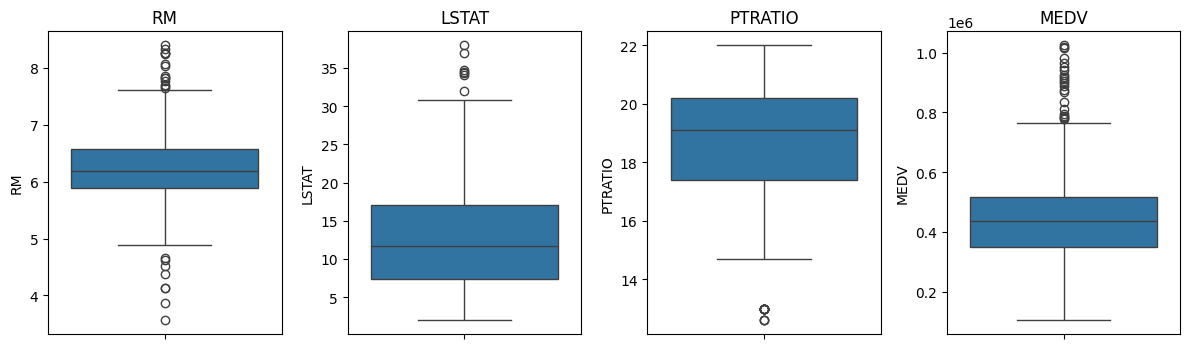

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot boxplots for all numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 5, i)  # Adjust grid size as needed
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Detect Outliers using IQR Method

In [ ]:
# Function to detect outliers
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")
    return outliers

# Detect outliers for all numerical columns
for col in num_cols:
    detect_outliers_iqr(df, col)

RM: 22 outliers
LSTAT: 7 outliers
PTRATIO: 13 outliers
MEDV: 22 outliers


Remove Outliers

In [ ]:
def remove_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

# Remove outliers for all numerical columns
for col in num_cols:
    df = remove_outliers_iqr(df, col)

print("Data shape after removing outliers:", df.shape)

#winzorization
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[col] = data[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)
    return data

# Cap outliers for all numerical columns
for col in num_cols:
    df = cap_outliers(df, col)

print("Outliers capped successfully!")

Data shape after removing outliers: (421, 4)
Outliers capped successfully!


#Feature Selection

In [ ]:
# Step 1: Correlation matrix to see which features correlate with target 'MEDV'
corr_matrix = df.corr()
print(corr_matrix['MEDV'].sort_values(ascending=False))

# Step 2: Choose important features
# Usually features with higher correlation with 'MEDV' are selected
# Example: if correlation > 0.4 or <-0.4
important_features = corr_matrix['MEDV'][(corr_matrix['MEDV'] > 0.4) | (corr_matrix['MEDV'] < -0.4)].index.tolist()
print("Selected features:", important_features)

# Step 3: Create a new dataframe with only important features
df_selected = df[important_features]

# Step 4: Check the new dataframe
print(df_selected.head())

MEDV       1.000000
RM         0.697209
PTRATIO   -0.519034
LSTAT     -0.760670
Name: MEDV, dtype: float64
Selected features: ['RM', 'LSTAT', 'PTRATIO', 'MEDV']
      RM  LSTAT  PTRATIO      MEDV
0  6.575   4.98     15.3  504000.0
1  6.421   9.14     17.8  453600.0
2  7.185   4.03     17.8  728700.0
3  6.998   2.94     18.7  701400.0
4  7.147   5.33     18.7  760200.0


#Feature Engineering


In [ ]:
# df is  original dataframe

df['TOTAL_ROOMS'] = df['RM'] * df['PTRATIO']  # just an example, total rooms per student ratio
df['LSTAT_PCT'] = df['LSTAT'] / 100  # percent of lower status population
df['RM_LSTAT_RATIO'] = df['RM'] / (df['LSTAT'] + 1)  # ratio of rooms to lower status
df['PTRATIO_LSTAT'] = df['PTRATIO'] * df['LSTAT']  # interaction between pupil-teacher ratio and lower status
df['RM_SQ'] = df['RM'] ** 2  # squared rooms to capture non-linear effect

# Preview the new features
print(df.head())

      RM  LSTAT  PTRATIO      MEDV  TOTAL_ROOMS  LSTAT_PCT  RM_LSTAT_RATIO  \
0  6.575   4.98     15.3  504000.0     100.5975     0.0498        1.099498   
1  6.421   9.14     17.8  453600.0     114.2938     0.0914        0.633235   
2  7.185   4.03     17.8  728700.0     127.8930     0.0403        1.428429   
3  6.998   2.94     18.7  701400.0     130.8626     0.0294        1.776142   
4  7.147   5.33     18.7  760200.0     133.6489     0.0533        1.129068   

   PTRATIO_LSTAT      RM_SQ  
0         76.194  43.230625  
1        162.692  41.229241  
2         71.734  51.624225  
3         54.978  48.972004  
4         99.671  51.079609  


#Splitting Dataset

In [ ]:
from sklearn.model_selection import train_test_split

# Assuming df is your dataframe and 'MEDV' is the target
X = df.drop('MEDV', axis=1)  # Features
y = df['MEDV']               # Target

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (391, 8)
X_test shape: (98, 8)
y_train shape: (391,)
y_test shape: (98,)


#Train a regression model

LinearRegression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print("R² Score:", r2_lr)

Linear Regression Results:
R² Score: 0.81204169310818


Gradient Boosting Regression

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the model
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Predict on test set
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("\nGradient Boosting Regression Results:")
print("R² Score:", r2_gb)


Gradient Boosting Regression Results:
R² Score: 0.8386365200814013


Evaluate (MAE, RMSE)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# For Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Evaluation:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

# For Gradient Boosting
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("\nGradient Boosting Evaluation:")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)

Linear Regression Evaluation:
MAE: 50207.80792122058
RMSE: 64271.86327490427

Gradient Boosting Evaluation:
MAE: 46693.43910029735
RMSE: 59551.50670131151


Visualize predicted prices compared to actual prices.

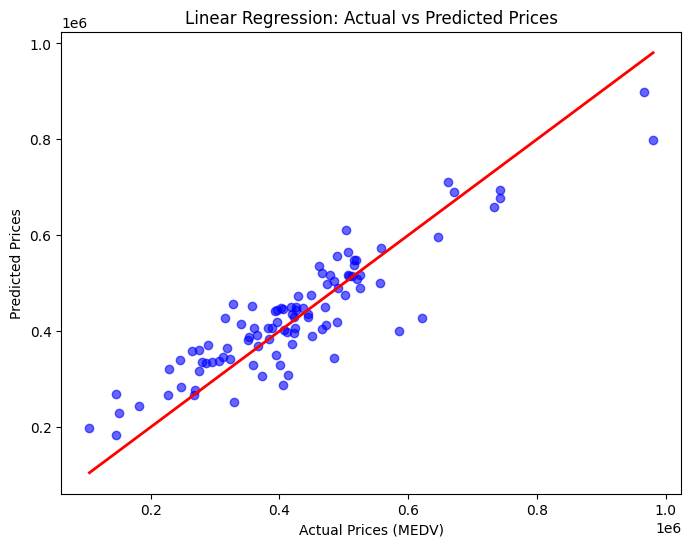

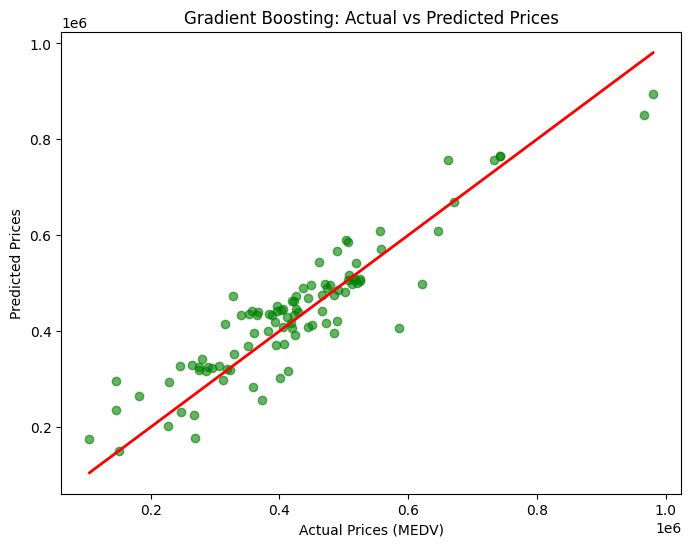

In [ ]:
import matplotlib.pyplot as plt

# Linear Regression predictions vs actual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel("Actual Prices (MEDV)")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.show()

# Gradient Boosting predictions vs actual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_gb, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel("Actual Prices (MEDV)")
plt.ylabel("Predicted Prices")
plt.title("Gradient Boosting: Actual vs Predicted Prices")
plt.show()

Pie Chart for House Prices

In [ ]:
print("Min MEDV:", y_test.min())
print("Max MEDV:", y_test.max())

Min MEDV: 105000.0
Max MEDV: 980700.0


dynamic bins based on data

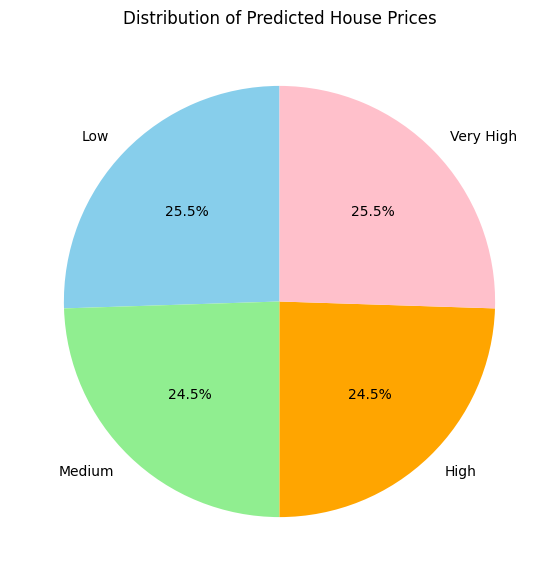

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Example using Gradient Boosting predictions
y_pred = y_pred_gb  # or y_pred_lr

# Create 4 bins automatically using quantiles
bins = np.quantile(y_pred, [0, 0.25, 0.5, 0.75, 1.0])
labels = ['Low', 'Medium', 'High', 'Very High']

# Categorize predicted prices
y_pred_cat = pd.cut(y_pred, bins=bins, labels=labels, include_lowest=True)

# Count number of houses in each category
category_counts = y_pred_cat.value_counts()

# Plot pie chart
plt.figure(figsize=(7,7))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['skyblue','lightgreen','orange','pink'])
plt.title("Distribution of Predicted House Prices")
plt.show()